# Build a model

Are the signals from `pbs-1`, `pbs-2`, and `pbs-3` sufficiently discrimatory of human breast cancer?


```
variation.update({
    'q_high': 0.95
})
```

## 0. Initializations

In [1]:
## 0. Initializations
# -- imports --
import anndata as ad
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns

import random

from collections import defaultdict

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from statistics import median

from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes
from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

## 1. Preprocessing Data

1. Subset data to samples that have a potential biological signal.
2. Determine the distribution of number of samples per subject - use to downsample for parity.
3. Determine the distribution of number of cells per subject - use to downsample for parity

In [3]:
initial = {
    'q_low': 0.25,
    'q_high': 0.75
}
variation = initial.copy()
variation.update({
    'q_high': 0.95
})
print(f"kwargs: {variation}")

kwargs: {'q_low': 0.25, 'q_high': 0.95}


In [4]:
# -- subset data --
subtype_to_adata = defaultdict(dict)
choices = ["pbs-1", "pbs-2", "pbs-3"]
for adata in gse.objects.values():
    if adata.uns['cell_population'] != 'Total':
        continue
    adata_noise = adata[adata.obs["is_noise"] == 1].copy()
    classify_noise_subtypes(adata_noise, **variation)
    conditions = [
        adata_noise.obs["pbs-1"] == 1,
        adata_noise.obs["pbs-2"] == 1,
        adata_noise.obs["pbs-3"] == 1,
    ]
    adata_noise.obs["pbs"] = np.select(conditions, choices, default="none")
    adata_pbs_only = adata_noise[adata_noise.obs["pbs"] != "none"]
    subtype_to_adata[adata_pbs_only.uns['cancer_type']].update({
        adata_pbs_only.uns['title'] : adata_pbs_only
    })

In [5]:
subtype_to_adata.keys()

dict_keys(['Normal', 'BRCA1 pre-neoplastic', 'Triple negative tumour', 'Triple negative BRCA1 tumour', 'HER2+ tumour', 'PR+ tumour', 'ER+ tumour'])

In [6]:
def print_data_stats(adata_collection):
    results = []
    for subtype, adatas in adata_collection.items():
        num_subjects = len(adatas)
        num_samples = [adata.n_obs for adata in adatas.values()]
        print(f"{subtype} - {num_samples}")
        results.append((subtype, num_subjects, min(num_samples), median(num_samples)))
    
    return pd.DataFrame(results, columns=['Cancer sub-type', '# Subjects', 'Min # Samples', 'Median # Samples'])

print_data_stats(subtype_to_adata)

Normal - [26, 68, 412, 11, 18, 34, 23, 48, 69, 28, 37, 26, 124]
BRCA1 pre-neoplastic - [38, 28, 60, 50]
Triple negative tumour - [24, 57, 13, 55]
Triple negative BRCA1 tumour - [39, 73, 152, 252]
HER2+ tumour - [46, 231, 42, 6, 73, 364]
PR+ tumour - [31]
ER+ tumour - [196, 152, 89, 66, 11, 45, 125, 42, 73, 76, 40, 65, 71, 20, 268, 57, 443, 11]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,13,11,34.0
1,BRCA1 pre-neoplastic,4,28,44.0
2,Triple negative tumour,4,13,39.5
3,Triple negative BRCA1 tumour,4,39,112.5
4,HER2+ tumour,6,6,59.5
5,PR+ tumour,1,31,31.0
6,ER+ tumour,18,11,68.5


### 1.a. Decisions

1. Exclude cancer sub-type `PR+ tumour` because there is only a single subject in the dataset.
2. Downsample subjects to `3` with a minimum of `50` samples.

### 1.b. Further subset data

Produces a dataset with the decisions.

In [7]:
def subset_data_for_modeling(require_min_subject=True, require_min_samples=True):
    results = {}
    for subtype, adatas in subtype_to_adata.items():
        if require_min_subject and subtype == 'PR+ tumour':
            # only has one subject, exclude
            continue
        valid_subjects_to_adata = defaultdict(dict)
        for adata in adatas.values():
            if require_min_samples and adata.n_obs < 50:
                # exclude subjects with fewer than 50 samples
                continue
            valid_subjects_to_adata.update({
                adata.uns['title']: adata,
            })
        results[subtype] = valid_subjects_to_adata
    return results
valid_adatas = subset_data_for_modeling()

In [8]:
print_data_stats(valid_adatas)

Normal - [68, 412, 69, 124]
BRCA1 pre-neoplastic - [60, 50]
Triple negative tumour - [57, 55]
Triple negative BRCA1 tumour - [73, 152, 252]
HER2+ tumour - [231, 73, 364]
ER+ tumour - [196, 152, 89, 66, 125, 73, 76, 65, 71, 268, 57, 443]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,4,68,96.5
1,BRCA1 pre-neoplastic,2,50,55.0
2,Triple negative tumour,2,55,56.0
3,Triple negative BRCA1 tumour,3,73,152.0
4,HER2+ tumour,3,73,231.0
5,ER+ tumour,12,57,82.5


### 1.3. Utility to Generate Dataset for Modeling

Creates a list of dataframe from the AnnDatas that represents all cancer sub-types (except for `PR+ tumour`), with the following characteristics:

1. `3` subjects per sub-type, `6` sub-types = `18` total subjects
2. `1` dataframe per subject
3. Columns
   1. `has_cancer`
   2. `cancer_type`
   3. `cell_population`
   4. `menopause_status`
   5. `pbs-1`
   6. `pbs-2`
   7. `pbs-3`

Separating the subjects to a row will simplify using the leave-one-out strategy.

In [9]:
def generate_dataframe_for_modeling(adata, *, downsample=True):
    results = []
    for adatas in adata.values():
        if downsample:
            subjects = np.random.choice(list(adatas.keys()), 3)
        else:
            subjects = adatas.keys()

        for subject in subjects:
            adata = adatas[subject]
            df = pd.DataFrame({
                'pbs-1': adata.obs['pbs-1'].astype(int),
                'pbs-2': adata.obs['pbs-2'].astype(int),
                'pbs-3': adata.obs['pbs-3'].astype(int),
            })
            df['has_cancer'] = (adata.uns['cancer_type'] != 'Normal')
            df['cancer_type'] = str(adata.uns['cancer_type'])
            df['cell_population'] = str(adata.uns['cell_population'])
            df['menopause_status'] = str(adata.uns['menopause_status'])
            
            results.append(df)
    return results

In [10]:
generate_dataframe_for_modeling(adata=valid_adatas)[0]

,pbs-1,pbs-2,pbs-3,has_cancer,cancer_type,cell_population,menopause_status
AAACGGGTCGCTTGTC-1,0,0,1,False,Normal,Total,Pre
AACTCTTTCTACTTAC-1,0,1,0,False,Normal,Total,Pre
AAGGTTCTCAGCTCTC-1,0,1,0,False,Normal,Total,Pre
ACAGCCGCATGCATGT-1,0,1,0,False,Normal,Total,Pre
ACCAGTAAGCGATAGC-1,0,1,0,False,Normal,Total,Pre
...,...,...,...,...,...,...,...
TGGTTAGTCCGCAGTG-1,0,1,0,False,Normal,Total,Pre
TGTGTTTCACCAGGCT-1,0,1,0,False,Normal,Total,Pre
TTAGTTCTCGGCTTGG-1,0,1,0,False,Normal,Total,Pre
TTGGAACAGCGTAATA-1,0,1,0,False,Normal,Total,Pre


## 2. Build the classifier

In [11]:
def logistic_regression_loo_classifier(dfs, *, by_subjects=True, as_dict=False, model=None, target='cancer_type'):
    loo = LeaveOneOut()
    y_true, y_pred = [], []
    
    for train_idx, test_idx in loo.split(dfs):
        train_df = pd.concat([dfs[i] for i in train_idx])
        # there will only ever be one in the test
        test_df = dfs[test_idx[0]]
    
        X_train = train_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_train = train_df[target].values
    
        X_test = test_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_test = test_df[target].values

        if not model:
            model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
    
        if by_subjects:
            counts = np.unique(model.predict(X_test), return_counts=True)
            # return the majority vote for the subject
            y_pred.append(counts[0][np.argmax(counts[1])])
            y_true.append(test_df[target].iloc[0])
        else:
            y_pred.extend(model.predict(X_test))
            y_true.extend(y_test)
    
    return classification_report(y_true, y_pred, output_dict=as_dict)

### 2.1. Explore other models

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
from sklearn.exceptions import UndefinedMetricWarning

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=3, weights='distance'),
    'Naive Bayes': GaussianNB()
}

### 2.2. Model ANY cancer

#### 2.3.1 Need to downsample to proceed

The data is not balanced in several ways:
- Subjects skew to having cancer
- Sample count per subject varies

To address this, build several models for different views that are more balanced:
- Normal vs Abnormal
  - Abnormal can be any combination of cancer subjects. For example, group cancer by comparable subject count.
- Subset subjects to get a balanced 

In [13]:
dfs = generate_dataframe_for_modeling(adata=valid_adatas, downsample=False)

In [14]:
dfs_cancer = []
dfs_normal = []

for df in dfs:
    if df['cancer_type'].unique()[0] == 'Normal':
        dfs_normal.append(df)
    else:
        dfs_cancer.append(df)

In [15]:
def get_balanced_dataset(minority_dfs, majority_dfs, num_minority_subjects=6):
    # select the normal subjects first, its the smaller number of total subjects
    some_minority = random.sample(minority_dfs, k=min(num_minority_subjects, len(minority_dfs)))
    # total number of cells (samples) to use for downsampling the abnormal (cancer) subjects
    num_minority_cells = sum([df.count().unique()[0] for df in some_minority])

    majority_pool = majority_dfs.copy()
    some_majority = []
    num_majority_cells = 0
    # iterate over cancer subjects
    for _ in majority_dfs:
        major = majority_pool.pop(random.randrange(len(majority_pool)))
        major_count = major.count().unique()[0]
        if major_count > num_minority_cells:
            continue
        some_majority.append(major)
        num_majority_cells += major_count
        if num_majority_cells >= num_minority_cells:
            break

    # print(num_majority_cells, num_minority_cells)
    return some_minority, some_majority
    
balanced_dfs_normal, balanced_dfs_cancer = get_balanced_dataset(dfs_normal, dfs_cancer)   

In [16]:
def report_has_cancer(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                balanced_dfs_normal, dfs = get_balanced_dataset(minority, majority)
                dfs.extend(balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(dfs, by_subjects=False, as_dict=True, model=model, target="has_cancer")
                reports.append(pd.DataFrame(report).T)
        
            avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {avg_report}")
            print()
            model_avg_report[model_name] = avg_report
        return model_avg_report

report_has_cancer(dfs_normal, dfs_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score      support
False          0.564782  0.945884  0.706253   673.000000
True           0.878054  0.362393  0.507341   782.410000
accuracy       0.633911  0.633911  0.633911     0.633911
macro avg      0.721418  0.654138  0.606797  1455.410000
weighted avg   0.733798  0.633911  0.600923  1455.410000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
False          0.573418  0.945186  0.712535   673.000000
True           0.887276  0.394424  0.540398   797.220000
accuracy       0.648323  0.648323  0.648323     0.648323
macro avg      0.730347  0.669805  0.626467  1470.220000
weighted avg   0.744322  0.648323  0.620896  1470.220000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score      support
False          0.017273  0.000520  0.001002   673.000000
True           0.534373  0.993914  0.694682  

{'Logistic Regression':               precision    recall  f1-score      support
 False          0.564782  0.945884  0.706253   673.000000
 True           0.878054  0.362393  0.507341   782.410000
 accuracy       0.633911  0.633911  0.633911     0.633911
 macro avg      0.721418  0.654138  0.606797  1455.410000
 weighted avg   0.733798  0.633911  0.600923  1455.410000,
 'Decision Tree':               precision    recall  f1-score      support
 False          0.573418  0.945186  0.712535   673.000000
 True           0.887276  0.394424  0.540398   797.220000
 accuracy       0.648323  0.648323  0.648323     0.648323
 macro avg      0.730347  0.669805  0.626467  1470.220000
 weighted avg   0.744322  0.648323  0.620896  1470.220000,
 'KNN':               precision    recall  f1-score      support
 False          0.017273  0.000520  0.001002   673.000000
 True           0.534373  0.993914  0.694682   781.830000
 accuracy       0.532926  0.532926  0.532926     0.532926
 macro avg      0.27582

In [25]:
def report_cancer_sub_types(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                balanced_dfs_normal, dfs = get_balanced_dataset(minority, majority)
                dfs.extend(balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(dfs, by_subjects=False, as_dict=True, model=model)
                reports.append(pd.DataFrame(report).T)
        
            avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {avg_report}")
            print()
            model_avg_report[model_name] = avg_report
        return model_avg_report

# report_cancer_sub_types(dfs_normal, dfs_cancer)

In [26]:
targets = ['ER+ tumour',]
dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
avg_reports = report_cancer_sub_types(dfs_normal, dfs_target_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.905399  0.478879  0.622530   779.880000
Normal         0.614543  0.945022  0.743742   673.000000
accuracy       0.696375  0.696375  0.696375     0.696375
macro avg      0.759971  0.711951  0.683136  1452.880000
weighted avg   0.771217  0.696375  0.680097  1452.880000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.907667  0.479047  0.622994   802.020000
Normal         0.608316  0.945022  0.738958   673.000000
accuracy       0.693194  0.693194  0.693194     0.693194
macro avg      0.757991  0.712034  0.680976  1475.020000
weighted avg   0.771700  0.693194  0.677334  1475.020000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.539476  0.996819  0.699458   799.430000
Normal         0.000000  0.000000  0.000000  

In [19]:
# targets = ['HER2+ tumour', 'Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [20]:
# targets = ['Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [21]:
# targets = ['Triple negative tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [22]:
# targets = ['BRCA1 pre-neoplastic']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [107]:
def figure_for_poster(avg_report, minority_label="True", majority_label="False", small=False):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np
    
    # ── DATA from avg_report ─────────────────────────────────────────────────────
    support_false   = avg_report.loc[majority_label,     "support"]
    support_true    = avg_report.loc[minority_label,      "support"]
    recall_false    = avg_report.loc[majority_label,     "recall"]
    recall_true     = avg_report.loc[minority_label,      "recall"]
    precision_false = avg_report.loc[majority_label,     "precision"]
    precision_true  = avg_report.loc[minority_label,      "precision"]
    f1_false        = avg_report.loc[majority_label,     "f1-score"]
    f1_true         = avg_report.loc[minority_label,      "f1-score"]
    accuracy        = avg_report.loc["accuracy",  "f1-score"]
    macro_f1        = avg_report.loc["macro avg", "f1-score"]
    
    tn = round(support_false * recall_false)
    fp = round(support_false * (1 - recall_false))
    fn = round(support_true  * (1 - recall_true))
    tp = round(support_true  * recall_true)
    
    cm      = np.array([[tn, fp], [fn, tp]])
    support = [support_false, support_true]
    blue    = "#0072B2"
    orange  = "#D55E00"
    
    # ── FIGURE ───────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8, 5))
    
    ax_cm     = fig.add_axes([0.05, 0.10, 0.50, 0.80])

    if small:
        font_sizes = [26, 20, 20]
    else:
        font_sizes = [32, 26, 20]
    
    # ── CONFUSION MATRIX ─────────────────────────────────────────────────────────
    if small:
        classes = [f"{minority_label}", f"{majority_label}"]
    else:
        classes = [f"{minority_label}\n(no cancer)", f"{majority_label}\n(cancer)"]
    
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / support[i] if support[i] > 0 else 0
     
            if i == j:
                color = blue
                alpha = 0.15 + pct * 0.75
            else:
                color = orange
                alpha = 0.10 + pct * 0.70

            if small:
                rect = patches.FancyBboxPatch(
                    (j + 0.08, 1 - i + 0.08), 0.84, 0.84,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            else:
                rect = patches.FancyBboxPatch(
                    (j + 0.04, 1 - i + 0.04), 0.92, 0.92,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            ax_cm.add_patch(rect)
     
            text_color = "#00274C"
            if small:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.35, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
            else:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.28, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
     
    ax_cm.set_xticks([0.5, 1.5])
    ax_cm.set_xticklabels(classes, fontsize=font_sizes[2], color="#00274C")
    ax_cm.set_yticks([0.5, 1.5])
    ax_cm.set_yticklabels(classes[::-1], fontsize=font_sizes[2])
    ax_cm.set_xlim(0, 2)
    ax_cm.set_ylim(0, 2)
    ax_cm.set_xlabel("predicted label", fontsize=font_sizes[2])
    ax_cm.set_ylabel("true label", fontsize=font_sizes[2])
    ax_cm.spines[:].set_visible(False)
    ax_cm.tick_params(length=0)
    
    # from matplotlib.patches import Patch
    # legend_elements = [
    #     Patch(facecolor=blue,   alpha=0.8, label="correct"),
    #     Patch(facecolor=orange, alpha=0.8, label="misclassified"),
    # ]
    # ax_metric.legend(handles=legend_elements,
    #                  loc="lower right",
    #                  bbox_to_anchor=(1, -0.01),
    #                  frameon=False, fontsize=8,
    #                  ncol=1, handlelength=1)
    
    # ── METRICS PANEL ────────────────────────────────────────────────────────────
    # ax_metric.axis("off")
    
    # ax_metric.text(0, 1.00, "accuracy",       transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    # ax_metric.text(0, 0.92, f"{accuracy:.1%}", transform=ax_metric.transAxes,
    #                fontsize=20, fontweight="500")
    # ax_metric.text(0, 0.82, "macro F1",       transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    # ax_metric.text(0, 0.74, f"{macro_f1:.3f}", transform=ax_metric.transAxes,
    #                fontsize=20, fontweight="500")
    
    # ax_metric.axhline(y=0.70, xmin=0, xmax=1,
    #                   color="#CCCCCC", linewidth=0.5)
    
    # ax_metric.text(0, 0.66, "recall / F1 by class", transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    
    # metrics = [
    #     ("no cancer recall", recall_false, blue),
    #     ("cancer recall",    recall_true,  orange),
    #     ("no cancer F1",     f1_false,     blue),
    #     ("cancer F1",        f1_true,      orange),
    # ]
    
    # bar_y = [0.58, 0.46, 0.31, 0.19]
    
    # for (label, val, color), y in zip(metrics, bar_y):
    #     ax_metric.text(0, y + 0.02, label, transform=ax_metric.transAxes,
    #                    fontsize=8, color="white")
    #     ax_metric.text(1, y + 0.02, f"{val*100:.2f}%", transform=ax_metric.transAxes,
    #                    fontsize=8, color="black", ha="right")
    #     ax_metric.add_patch(patches.FancyBboxPatch(
    #         (0, y), 1, 0.06,
    #         boxstyle="round,pad=0.005",
    #         transform=ax_metric.transAxes,
    #         facecolor="#EEEEEE", linewidth=0, clip_on=False
    #     ))
    #     if val > 0.001:
    #         ax_metric.add_patch(patches.FancyBboxPatch(
    #             (0, y), val, 0.06,
    #             boxstyle="round,pad=0.005",
    #             transform=ax_metric.transAxes,
    #             facecolor=color, alpha=0.8, linewidth=0, clip_on=False
    #         ))
    
    # ax_metric.axhline(y=0.14, xmin=0, xmax=1,
    #                   color="#CCCCCC", linewidth=0.5)
    
    # ax_metric.text(0, 0.08, f"no cancer  n={int(support_false):,}",
    #                transform=ax_metric.transAxes, fontsize=8, color="gray")
    # ax_metric.text(0, 0.00, f"cancer     n={int(support_true):,}",
    #                transform=ax_metric.transAxes, fontsize=8, color="gray")
    
    # plt.suptitle("Decision Tree — mean classification report", fontsize=11, y=0.97)
    plt.rcParams.update({
        'axes.labelcolor': "#00274C",
        'text.color': "#00274C",
        'xtick.labelcolor': "#00274C",
        'ytick.labelcolor': "#00274C",
    })
    if small:
        plt.savefig("images/umsi-expo-postcard.png", dpi=300, bbox_inches="tight", transparent=True)
    else:
        plt.savefig("images/umsi-expo-figure-4.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

In [28]:
avg_report = avg_reports['Decision Tree']

In [30]:
avg_report

,precision,recall,f1-score,support
ER+ tumour,0.907667,0.479047,0.622994,802.020000
Normal,0.608316,0.945022,0.738958,673.000000
accuracy,0.693194,0.693194,0.693194,0.693194
macro avg,0.757991,0.712034,0.680976,1475.020000
weighted avg,0.771700,0.693194,0.677334,1475.020000


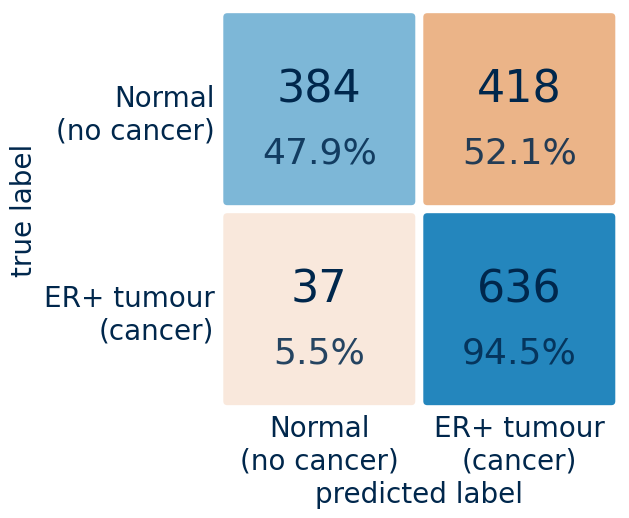

In [95]:
figure_for_poster(avg_report, "Normal", "ER+ tumour")

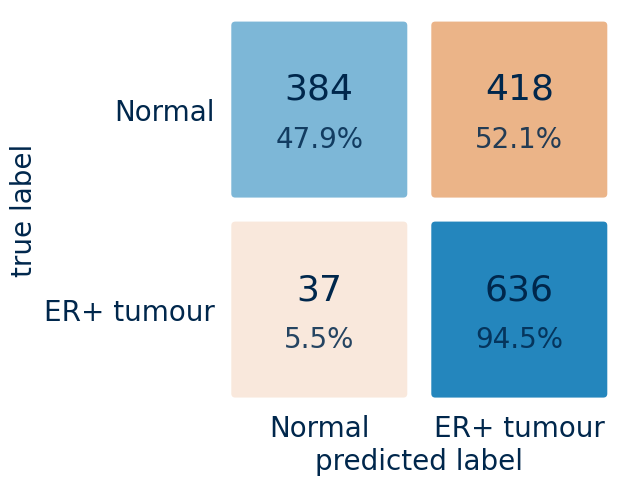

In [108]:
figure_for_poster(avg_report, "Normal", "ER+ tumour", small=True)